Load Data & Basic Cleaning

In [50]:
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import (
    HistGradientBoostingRegressor,
    RandomForestRegressor,
    ExtraTreesRegressor,
)
from sklearn.metrics import mean_absolute_error, mean_squared_error

DATA    = Path('../data')
RESULTS = Path('results')
RESULTS.mkdir(parents=True, exist_ok=True)

train      = pd.read_csv(DATA / 'train_test.csv')
validation = pd.read_csv(DATA / 'validation.csv')
december   = pd.read_csv(DATA / 'december_chart_inputs.csv')

train['date']      = pd.to_datetime(train['date'])
validation['date'] = pd.to_datetime(validation['date'])
december['date']   = pd.to_datetime(december['date'])

print('Train     :', train.shape, '|', train['date'].min().date(), '->', train['date'].max().date())
print('Validation:', validation.shape)
print('December  :', december.shape)

Train     : (48000, 14) | 2025-01-01 -> 2025-10-31
Validation: (12000, 13)
December  : (31, 7)


In [27]:
def basic_clean(df):
    """
    Row-level fixes that require no fitting:
    - abs(weight)        : sign errors in weight records
    - distance <= 0 → NaN: physically impossible
    No imputation here — that must be fitted on train only.
    """
    df = df.copy()
    df['weight'] = df['weight'].abs()
    df.loc[df['distance'] <= 0, 'distance'] = np.nan
    return df


train_raw = basic_clean(train)
val_raw   = basic_clean(validation)
dec_raw   = december.copy()

print('Missing after basic clean:')
for name, df in [('train', train_raw), ('validation', val_raw)]:
    print(f'  {name}: weight={df["weight"].isna().sum()}, '
          f'market_index={df["market_index"].isna().sum()}, '
          f'distance={df["distance"].isna().sum()}')

Missing after basic clean:
  train: weight=300, market_index=374, distance=0
  validation: weight=165, market_index=249, distance=0


Helper Functions

All imputers and encoders accept a `fit_df` argument — only ever the training window.

In [28]:
def haversine(lat1, lon1, lat2, lon2):
    """Straight-line geographic distance in miles."""
    R = 3958.8
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    return R * 2 * np.arcsin(np.sqrt(a))

In [29]:
def fit_imputers(fit_df):
    """
    Learn fill values from the training window only.
    Returns a dict of lookup tables to apply to any split.
    """
    # weight: median per equipment type
    weight_medians = fit_df.groupby('equipment')['weight'].median()
    global_weight  = fit_df['weight'].median()

    # market_index: median per calendar month
    market_medians = fit_df.groupby(fit_df['date'].dt.to_period('M'))['market_index'].median()
    global_market  = fit_df['market_index'].median()

    return {
        'weight_medians': weight_medians,
        'global_weight':  global_weight,
        'market_medians': market_medians,
        'global_market':  global_market,
    }


def apply_imputers(df, imputers):
    """
    Fill missing values using lookup tables fitted on train window.
    Falls back to global median for unseen categories or future months.
    """
    df = df.copy()

    # weight
    mask = df['weight'].isna()
    df.loc[mask, 'weight'] = (
        df.loc[mask, 'equipment']
        .map(imputers['weight_medians'])
        .fillna(imputers['global_weight'])
    )

    # market_index
    mask = df['market_index'].isna()
    df.loc[mask, 'market_index'] = (
        df.loc[mask, 'date'].dt.to_period('M')
        .map(imputers['market_medians'])
        .fillna(imputers['global_market'])
    )

    return df

In [30]:
def fit_encoders(fit_df):
    """
    Fit city target encodings (median posted_rate per city)
    strictly from the training window — no leakage.
    """
    global_median     = fit_df['posted_rate'].median()
    pickup_rate_map   = fit_df.groupby('pickup')['posted_rate'].median()
    delivery_rate_map = fit_df.groupby('delivery')['posted_rate'].median()
    return {
        'global_median':     global_median,
        'pickup_rate_map':   pickup_rate_map,
        'delivery_rate_map': delivery_rate_map,
    }


def create_features(df, encoders):
    """
    Build all features. Encoders must be pre-fitted on the training window.
    """
    df = df.copy()

    # Date
    df['month']        = df['date'].dt.month
    df['day_of_month'] = df['date'].dt.day
    df['day_of_week']  = df['date'].dt.dayofweek
    df['week_of_year'] = df['date'].dt.isocalendar().week.astype(int)
    df['quarter']      = df['date'].dt.quarter
    df['is_weekend']   = (df['day_of_week'] >= 5).astype(int)

    # Geography
    df['geo_distance']   = haversine(
        df['pickup_lat'], df['pickup_lon'],
        df['delivery_lat'], df['delivery_lon']
    )
    df['distance_ratio'] = df['distance'] / df['geo_distance'].replace(0, np.nan)

    # Load
    df['weight_per_mile'] = df['weight'] / df['distance'].replace(0, np.nan)

    # Equipment ordinal (Dry Van < Reefer < Flatbed by typical rate)
    df['equipment_code'] = df['equipment'].map({'Dry Van': 0, 'Reefer': 1, 'Flatbed': 2}).fillna(0).astype(int)

    # City target encodings
    fallback = encoders['global_median']
    df['pickup_rate_enc']   = df['pickup'].map(encoders['pickup_rate_map']).fillna(fallback)
    df['delivery_rate_enc'] = df['delivery'].map(encoders['delivery_rate_map']).fillna(fallback)

    return df

In [31]:
def prepare_window(train_window_raw, valid_window_raw):
    """
    Given raw (basic-cleaned) train and validation slices:
    1. Fit imputers on train_window only
    2. Fit encoders on train_window only
    3. Apply both to train and valid
    4. Return fully-featured DataFrames

    This ensures zero leakage from the validation window.
    """
    imp      = fit_imputers(train_window_raw)
    enc      = fit_encoders(train_window_raw)  # uses posted_rate from train only

    train_imp = apply_imputers(train_window_raw, imp)
    valid_imp = apply_imputers(valid_window_raw, imp)

    train_feat = create_features(train_imp, enc)
    valid_feat = create_features(valid_imp, enc)

    return train_feat, valid_feat


print('Helper functions defined.')

Helper functions defined.


Feature Sets

Experiment A — no quote_signal  
Experiment B — includes quote_signal

Rationale: EDA showed quote_signal had unstable correlation with the target across months. so i tested it explicitly rather than blindly including or excluding it.

In [32]:
TARGET = 'posted_rate'

FEATURES_A = [
    # Geography
    'pickup_lat', 'pickup_lon', 'delivery_lat', 'delivery_lon',
    'distance', 'geo_distance', 'distance_ratio',
    # Load
    'weight', 'weight_per_mile', 'equipment_code',
    # Market (no quote_signal)
    'market_index',
    # City encodings
    'pickup_rate_enc', 'delivery_rate_enc',
    # Date
    'month', 'day_of_month', 'day_of_week', 'week_of_year', 'quarter', 'is_weekend',
]

FEATURES_B = FEATURES_A + ['quote_signal']   # same as A but with quote_signal appended

print(f'Experiment A: {len(FEATURES_A)} features (no quote_signal)')
print(f'Experiment B: {len(FEATURES_B)} features (with quote_signal)')

Experiment A: 19 features (no quote_signal)
Experiment B: 20 features (with quote_signal)


Stage 1 — Screen Models on August Window

**Train:** Jan 2025 → Jul 2025 (7 months)  
**Validate:** Aug 2025 (1 month holdout)

All imputers and encoders fitted strictly on Jan–Jul data.

In [33]:
aug_train_raw = train_raw[train_raw['date'] < '2025-08-01'].copy()
aug_valid_raw = train_raw[
    (train_raw['date'] >= '2025-08-01') &
    (train_raw['date'] <  '2025-09-01')
].copy()

aug_train_feat, aug_valid_feat = prepare_window(aug_train_raw, aug_valid_raw)

print(f'Aug train: {aug_train_feat.shape}  {aug_train_raw["date"].min().date()} -> {aug_train_raw["date"].max().date()}')
print(f'Aug valid: {aug_valid_feat.shape}  {aug_valid_raw["date"].min().date()} -> {aug_valid_raw["date"].max().date()}')

# Verify no missing in features
missing_train = aug_train_feat[FEATURES_B].isna().sum().sum()
missing_valid = aug_valid_feat[FEATURES_B].isna().sum().sum()
print(f'Missing values — train: {missing_train}, valid: {missing_valid}')

Aug train: (33718, 26)  2025-01-01 -> 2025-07-31
Aug valid: (4759, 26)  2025-08-01 -> 2025-08-31
Missing values — train: 0, valid: 0


In [34]:
stage1_results = []

def evaluate(label, model, X_tr, y_tr, X_va, y_va):
    model.fit(X_tr, y_tr)
    preds = model.predict(X_va)
    mae   = mean_absolute_error(y_va, preds)
    rmse  = np.sqrt(mean_squared_error(y_va, preds))
    stage1_results.append({'Label': label, 'MAE': round(mae, 2), 'RMSE': round(rmse, 2)})
    print(f'{label:<45}  MAE={mae:>8.2f}  RMSE={rmse:>8.2f}')
    return model, preds

In [35]:
print('=== Experiment A (no quote_signal) ===')
Xtr_A = aug_train_feat[FEATURES_A];  ytr = aug_train_feat[TARGET]
Xva_A = aug_valid_feat[FEATURES_A];  yva = aug_valid_feat[TARGET]

hgb_A, _ = evaluate('A — HistGradientBoosting',
    HistGradientBoostingRegressor(max_iter=400, learning_rate=0.05, max_leaf_nodes=63, min_samples_leaf=20, random_state=42),
    Xtr_A, ytr, Xva_A, yva)

rf_A, _ = evaluate('A — RandomForest',
    RandomForestRegressor(n_estimators=300, min_samples_leaf=2, max_features='sqrt', n_jobs=-1, random_state=42),
    Xtr_A, ytr, Xva_A, yva)

et_A, _ = evaluate('A — ExtraTrees',
    ExtraTreesRegressor(n_estimators=300, min_samples_leaf=2, max_features='sqrt', n_jobs=-1, random_state=42),
    Xtr_A, ytr, Xva_A, yva)

=== Experiment A (no quote_signal) ===
A — HistGradientBoosting                       MAE=  169.39  RMSE=  643.92
A — RandomForest                               MAE=  177.38  RMSE=  637.80
A — ExtraTrees                                 MAE=  167.39  RMSE=  630.78


In [36]:
print('=== Experiment B (with quote_signal) ===')
Xtr_B = aug_train_feat[FEATURES_B]
Xva_B = aug_valid_feat[FEATURES_B]

hgb_B, _ = evaluate('B — HistGradientBoosting',
    HistGradientBoostingRegressor(max_iter=400, learning_rate=0.05, max_leaf_nodes=63, min_samples_leaf=20, random_state=42),
    Xtr_B, ytr, Xva_B, yva)

rf_B, _ = evaluate('B — RandomForest',
    RandomForestRegressor(n_estimators=300, min_samples_leaf=2, max_features='sqrt', n_jobs=-1, random_state=42),
    Xtr_B, ytr, Xva_B, yva)

et_B, _ = evaluate('B — ExtraTrees',
    ExtraTreesRegressor(n_estimators=300, min_samples_leaf=2, max_features='sqrt', n_jobs=-1, random_state=42),
    Xtr_B, ytr, Xva_B, yva)

=== Experiment B (with quote_signal) ===
B — HistGradientBoosting                       MAE=  193.22  RMSE=  651.94
B — RandomForest                               MAE=  195.14  RMSE=  643.69
B — ExtraTrees                                 MAE=  176.85  RMSE=  632.31


In [37]:
s1 = pd.DataFrame(stage1_results).sort_values('MAE')
print('\n=== Stage 1 Results (Aug holdout) ===')
print(s1.to_string(index=False))

best_label = s1.iloc[0]['Label']
print(f'\nBest in Stage 1: {best_label}')

# Determine best experiment (A or B) and best model type
best_exp   = 'A' if best_label.startswith('A') else 'B'
best_feats = FEATURES_A if best_exp == 'A' else FEATURES_B
print(f'Best experiment: {best_exp} → using {len(best_feats)} features')


=== Stage 1 Results (Aug holdout) ===
                   Label    MAE   RMSE
          A — ExtraTrees 167.39 630.78
A — HistGradientBoosting 169.39 643.92
          B — ExtraTrees 176.85 632.31
        A — RandomForest 177.38 637.80
B — HistGradientBoosting 193.22 651.94
        B — RandomForest 195.14 643.69

Best in Stage 1: A — ExtraTrees
Best experiment: A → using 19 features


Feature Importance Analysis & Pruning

We inspect feature importances from the best model in Stage 1.
Rather than dropping essential features blindly, we retain the highest-contributing features
while preserving calendar seasonality (e.g., day_of_week, day_of_month) and essential domain features
necessary for predicting time variations in held-out future dates (such as the December forecast).

Features kept (18): ['geo_distance', 'distance', 'pickup_rate_enc', 'delivery_lon', 'weight_per_mile', 'delivery_rate_enc', 'pickup_lon', 'distance_ratio', 'pickup_lat', 'delivery_lat', 'equipment_code', 'weight', 'week_of_year', 'market_index', 'day_of_week', 'day_of_month', 'month', 'is_weekend']
Features dropped (1): ['quarter']


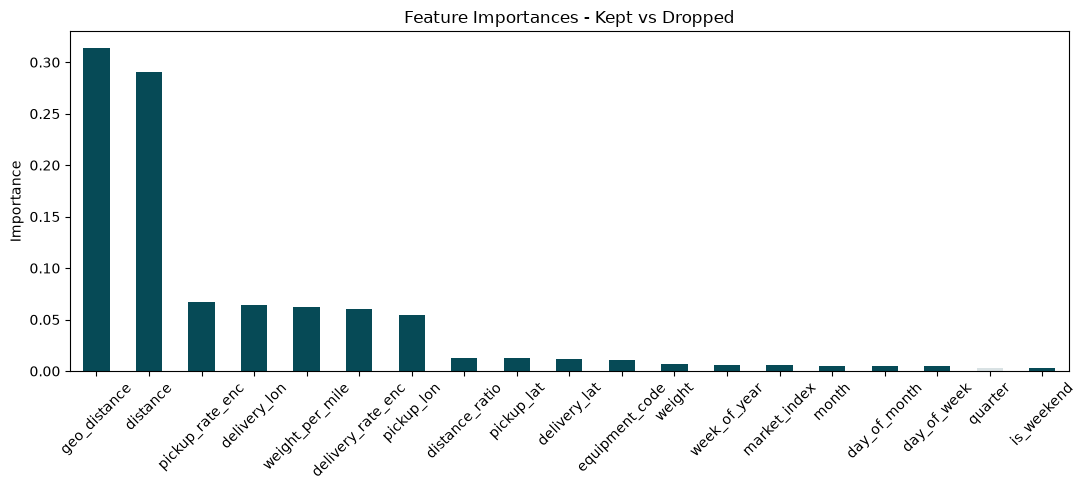

In [ ]:
# Feature importance from best Stage 1 model
imp_model = et_A if best_exp == 'A' else et_B
imp_feats = best_feats

importances = pd.Series(imp_model.feature_importances_, index=imp_feats).sort_values(ascending=False)

# Retain top cumulative contributors and ensure temporal seasonality features are preserved
CUMULATIVE_CUTOFF = 0.98
cum_importances = importances.cumsum() / importances.sum()
cutoff_keep = cum_importances[cum_importances <= CUMULATIVE_CUTOFF].index.tolist()
if len(cutoff_keep) < len(importances):
    cutoff_keep.append(importances.index[len(cutoff_keep)])

ESSENTIAL_FEATURES = ['day_of_week', 'day_of_month', 'month', 'week_of_year', 'is_weekend', 'equipment_code', 'market_index']
keep = list(dict.fromkeys(cutoff_keep + [f for f in ESSENTIAL_FEATURES if f in best_feats]))
drop = [f for f in best_feats if f not in keep]

print(f'Features kept ({len(keep)}): {keep}')
print(f'Features dropped ({len(drop)}): {drop}')

# Plot
fig, ax = plt.subplots(figsize=(11, 5))
colors = ['#064A56' if f in keep else '#D9E2E4' for f in importances.index]
importances.plot(kind='bar', ax=ax, color=colors)
ax.set_title('Feature Importances - Kept vs Dropped')
ax.set_ylabel('Importance')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
fig.savefig(RESULTS / 'modelling/feature_importances.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close(fig)


In [39]:
# Rebuild final feature set from the pruned list
# Preserve quote_signal decision from best experiment
FEATURES_FINAL = keep

print(f'Final feature set ({len(FEATURES_FINAL)}):')
for f in FEATURES_FINAL:
    print(f'  {f}  (importance={importances[f]:.4f})')

Final feature set (18):
  geo_distance  (importance=0.3143)
  distance  (importance=0.2905)
  pickup_rate_enc  (importance=0.0671)
  delivery_lon  (importance=0.0638)
  weight_per_mile  (importance=0.0626)
  delivery_rate_enc  (importance=0.0600)
  pickup_lon  (importance=0.0546)
  distance_ratio  (importance=0.0130)
  pickup_lat  (importance=0.0128)
  delivery_lat  (importance=0.0121)
  equipment_code  (importance=0.0107)
  weight  (importance=0.0072)
  week_of_year  (importance=0.0058)
  market_index  (importance=0.0056)
  day_of_week  (importance=0.0046)
  day_of_month  (importance=0.0049)
  month  (importance=0.0051)
  is_weekend  (importance=0.0025)


Stage 2 — Multi-Window Validation

Take the top 2 models from Stage 1 and evaluate across **three windows**:

| Window | Train | Validate |
|---|---|---|
| Aug | Jan–Jul | Aug |
| Sep | Jan–Aug | Sep |
| Oct | Jan–Sep | Oct |

Each window re-fits imputers and encoders on its own training portion — no cross-window leakage.

In [40]:
# Identify top 2 model types from Stage 1 (by MAE, ignoring experiment)
s1_by_model = (
    pd.DataFrame(stage1_results)
    .assign(model_type=lambda d: d['Label'].str.split('— ').str[1])
    .groupby('model_type')['MAE']
    .min()
    .sort_values()
)
print('Best MAE per model type across Stage 1:')
print(s1_by_model)

TOP2_MODELS = s1_by_model.index[:2].tolist()
print(f'\nTop 2 for Stage 2: {TOP2_MODELS}')

Best MAE per model type across Stage 1:
model_type
ExtraTrees              167.39
HistGradientBoosting    169.39
RandomForest            177.38
Name: MAE, dtype: float64

Top 2 for Stage 2: ['ExtraTrees', 'HistGradientBoosting']


In [41]:
def make_model(name):
    if name == 'HistGradientBoosting':
        return HistGradientBoostingRegressor(
            max_iter=400, learning_rate=0.05, max_leaf_nodes=63,
            min_samples_leaf=20, random_state=42
        )
    elif name == 'RandomForest':
        return RandomForestRegressor(
            n_estimators=300, min_samples_leaf=2,
            max_features='sqrt', n_jobs=-1, random_state=42
        )
    elif name == 'ExtraTrees':
        return ExtraTreesRegressor(
            n_estimators=300, min_samples_leaf=2,
            max_features='sqrt', n_jobs=-1, random_state=42
        )
    raise ValueError(f'Unknown model: {name}')

In [42]:
WINDOWS = [
    {'name': 'Aug', 'train_end': '2025-08-01', 'val_start': '2025-08-01', 'val_end': '2025-09-01'},
    {'name': 'Sep', 'train_end': '2025-09-01', 'val_start': '2025-09-01', 'val_end': '2025-10-01'},
    {'name': 'Oct', 'train_end': '2025-10-01', 'val_start': '2025-10-01', 'val_end': '2025-11-01'},
]

stage2_results = []

for w in WINDOWS:
    tr_raw = train_raw[train_raw['date'] < w['train_end']].copy()
    va_raw = train_raw[
        (train_raw['date'] >= w['val_start']) &
        (train_raw['date'] <  w['val_end'])
    ].copy()

    tr_feat, va_feat = prepare_window(tr_raw, va_raw)

    X_tr = tr_feat[FEATURES_FINAL];  y_tr = tr_feat[TARGET]
    X_va = va_feat[FEATURES_FINAL];  y_va = va_feat[TARGET]

    print(f'\n--- Window: {w["name"]} | Train {tr_raw["date"].min().date()} -> {tr_raw["date"].max().date()} '
          f'| Val {va_raw["date"].min().date()} -> {va_raw["date"].max().date()} '
          f'| train={len(tr_raw)} val={len(va_raw)} ---')

    for mname in TOP2_MODELS:
        m = make_model(mname)
        m.fit(X_tr, y_tr)
        preds = m.predict(X_va)
        mae   = mean_absolute_error(y_va, preds)
        rmse  = np.sqrt(mean_squared_error(y_va, preds))
        stage2_results.append({'Window': w['name'], 'Model': mname, 'MAE': round(mae, 2), 'RMSE': round(rmse, 2)})
        print(f'  {mname:<25}  MAE={mae:>8.2f}  RMSE={rmse:>8.2f}')


--- Window: Aug | Train 2025-01-01 -> 2025-07-31 | Val 2025-08-01 -> 2025-08-31 | train=33718 val=4759 ---
  ExtraTrees                 MAE=  165.00  RMSE=  630.92
  HistGradientBoosting       MAE=  170.42  RMSE=  643.63

--- Window: Sep | Train 2025-01-01 -> 2025-08-31 | Val 2025-09-01 -> 2025-09-30 | train=38477 val=4670 ---
  ExtraTrees                 MAE=  138.88  RMSE=  620.13
  HistGradientBoosting       MAE=  143.10  RMSE=  625.06

--- Window: Oct | Train 2025-01-01 -> 2025-09-30 | Val 2025-10-01 -> 2025-10-31 | train=43147 val=4853 ---
  ExtraTrees                 MAE=  138.60  RMSE=  655.25
  HistGradientBoosting       MAE=  153.01  RMSE=  661.14


=== Stage 2 MAE across windows ===
Window                   Aug     Oct     Sep    Mean_MAE
Model                                                   
ExtraTrees            165.00  138.60  138.88  147.493333
HistGradientBoosting  170.42  153.01  143.10  155.510000


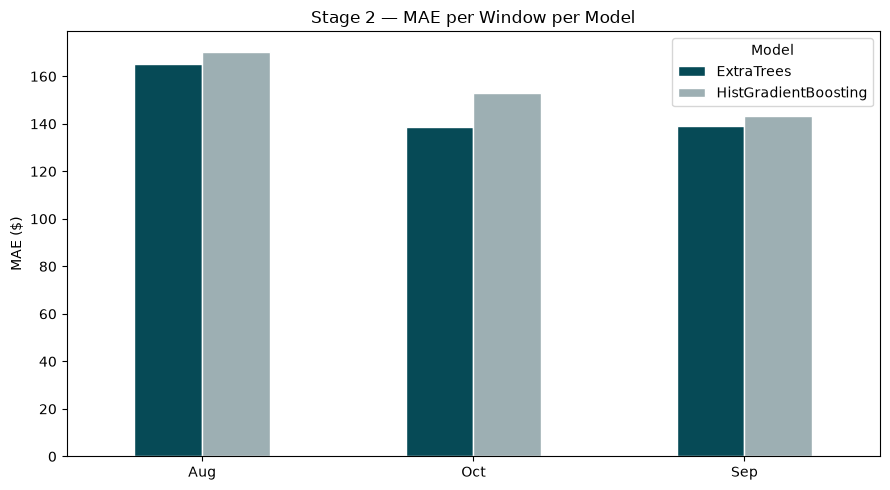

In [ ]:
s2 = pd.DataFrame(stage2_results)

# Pivot for readability
pivot = s2.pivot(index='Model', columns='Window', values='MAE')
pivot['Mean_MAE'] = pivot.mean(axis=1)
pivot = pivot.sort_values('Mean_MAE')

print('=== Stage 2 MAE across windows ===')
print(pivot.to_string())

# Plot
fig, ax = plt.subplots(figsize=(9, 5))
s2.pivot(index='Window', columns='Model', values='MAE').plot(
    kind='bar', ax=ax, color=['#064A56', '#9DAFB3'], edgecolor='white'
)
ax.set_title('Stage 2 — MAE per Window per Model')
ax.set_ylabel('MAE ($)')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=0)
ax.legend(title='Model')
plt.tight_layout()
fig.savefig(RESULTS / 'modelling/stage2_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close(fig)

Final Model Selection

In [44]:
BEST_MODEL_NAME = pivot.index[0]
BEST_MAE_MEAN   = pivot.loc[BEST_MODEL_NAME, 'Mean_MAE']

print(f'Selected model : {BEST_MODEL_NAME}')
print(f'Mean MAE (3 windows): {BEST_MAE_MEAN:.2f}')
print()
print('Window-by-window breakdown:')
print(pivot.loc[BEST_MODEL_NAME])

Selected model : ExtraTrees
Mean MAE (3 windows): 147.49

Window-by-window breakdown:
Window
Aug         165.000000
Oct         138.600000
Sep         138.880000
Mean_MAE    147.493333
Name: ExtraTrees, dtype: float64


Retrain on Full Training Data

Now that the model is selected, retrain on all 48,000 rows (Jan–Oct 2025).  
Imputers and encoders are fitted on the entire training set — there is no validation split to leak into.

In [45]:
# Fit imputers and encoders on full training data
full_imp = fit_imputers(train_raw)
full_enc = fit_encoders(train_raw)     # train_raw has posted_rate; val_raw does not

train_full_imp  = apply_imputers(train_raw, full_imp)
train_full_feat = create_features(train_full_imp, full_enc)

X_full = train_full_feat[FEATURES_FINAL]
y_full = train_full_feat[TARGET]

print('Retraining on full data:', X_full.shape)
print('Missing in X_full:', X_full.isna().sum().sum())

final_model = make_model(BEST_MODEL_NAME)
final_model.fit(X_full, y_full)
print('Done — final model trained.')

Retraining on full data: (48000, 18)
Missing in X_full: 0
Done — final model trained.


Residual Diagnostics (Oct window — most recent)

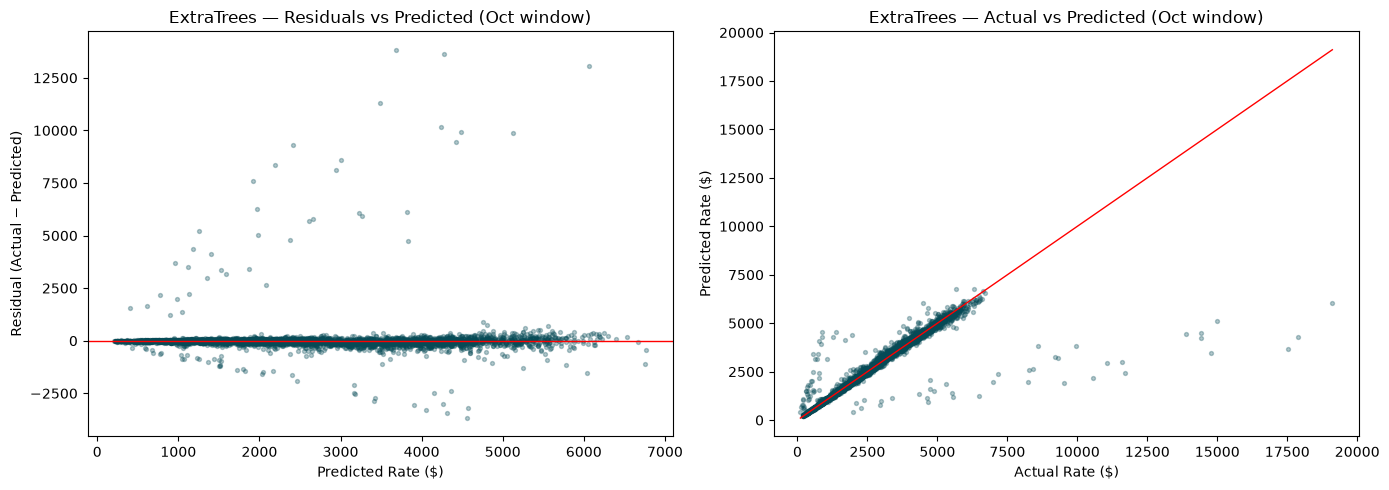

Oct window — MAE: 138.60  RMSE: 655.25


In [46]:
# Rerun Oct window for residual plot using final feature set
oct_tr_raw = train_raw[train_raw['date'] < '2025-10-01'].copy()
oct_va_raw = train_raw[
    (train_raw['date'] >= '2025-10-01') &
    (train_raw['date'] <  '2025-11-01')
].copy()

oct_tr_feat, oct_va_feat = prepare_window(oct_tr_raw, oct_va_raw)

diag_model = make_model(BEST_MODEL_NAME)
diag_model.fit(oct_tr_feat[FEATURES_FINAL], oct_tr_feat[TARGET])
diag_preds = diag_model.predict(oct_va_feat[FEATURES_FINAL])
y_diag     = oct_va_feat[TARGET].values

residuals = y_diag - diag_preds

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(diag_preds, residuals, alpha=0.3, s=8, color='#064A56')
axes[0].axhline(0, color='red', linewidth=1)
axes[0].set_xlabel('Predicted Rate ($)')
axes[0].set_ylabel('Residual (Actual − Predicted)')
axes[0].set_title(f'{BEST_MODEL_NAME} — Residuals vs Predicted (Oct window)')

axes[1].scatter(y_diag, diag_preds, alpha=0.3, s=8, color='#064A56')
mn, mx = y_diag.min(), y_diag.max()
axes[1].plot([mn, mx], [mn, mx], color='red', linewidth=1)
axes[1].set_xlabel('Actual Rate ($)')
axes[1].set_ylabel('Predicted Rate ($)')
axes[1].set_title(f'{BEST_MODEL_NAME} — Actual vs Predicted (Oct window)')

plt.tight_layout()
fig.savefig(RESULTS / 'modelling/ residuals.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close(fig)

oct_mae  = mean_absolute_error(y_diag, diag_preds)
oct_rmse = np.sqrt(mean_squared_error(y_diag, diag_preds))
print(f'Oct window — MAE: {oct_mae:.2f}  RMSE: {oct_rmse:.2f}')

Generate validation_predictions.csv

In [51]:
# Apply full-data imputers to validation set
val_imp  = apply_imputers(val_raw, full_imp)
val_feat = create_features(val_imp, full_enc)

print('Missing in validation features:', val_feat[FEATURES_FINAL].isna().sum().sum())

val_preds = np.clip(final_model.predict(val_feat[FEATURES_FINAL]), 1.0, None)

output = pd.DataFrame({
    'load_id':        validation['load_id'].values,
    'predicted_rate': np.round(val_preds, 2),
})

assert len(output) == 12000
assert output['predicted_rate'].isna().sum() == 0
assert (output['predicted_rate'] > 0).all()

OUTPUT = Path('..') / 'output'
OUTPUT.mkdir(parents=True, exist_ok=True)
out_path = OUTPUT / 'validation_predictions.csv'
output.to_csv(out_path, index=False)

print(f'Saved -> {out_path}')
print(f'Rows        : {len(output):,}')
print(f'Rate range  : ${output["predicted_rate"].min():.2f} -> ${output["predicted_rate"].max():.2f}')
print(f'Mean rate   : ${output["predicted_rate"].mean():.2f}')
print(f'Median rate : ${output["predicted_rate"].median():.2f}')
print()
print(output.head(10))

Missing in validation features: 0
Saved -> ..\output\validation_predictions.csv
Rows        : 12,000
Rate range  : $209.17 -> $7341.27
Mean rate   : $2401.11
Median rate : $2075.47

     load_id  predicted_rate
0  TE-000001          896.33
1  TE-000002         4916.21
2  TE-000003         5199.05
3  TE-000004         4033.74
4  TE-000005         1848.50
5  TE-000006         4466.12
6  TE-000007         5234.25
7  TE-000008         3152.09
8  TE-000009         1129.01
9  TE-000010         1206.15


Fill december-chart-inputs.csv

In [53]:
# Generate December predictions without modifying the source template
dec_model_raw = dec_raw.copy()

# Reconstruct route features omitted from the fixed seven-column template.
for city_role, latitude, longitude in [
    ('pickup', 'pickup_lat', 'pickup_lon'),
    ('delivery', 'delivery_lat', 'delivery_lon'),
]:
    city_locations = train_raw.groupby(city_role)[[latitude, longitude]].median()
    dec_model_raw[latitude] = dec_model_raw[city_role].map(city_locations[latitude])
    dec_model_raw[longitude] = dec_model_raw[city_role].map(city_locations[longitude])

dec_model_raw['market_index'] = (
    dec_model_raw['date'].dt.to_period('M')
    .map(full_imp['market_medians'])
    .fillna(full_imp['global_market'])
)
if 'quote_signal' in FEATURES_FINAL:
    dec_model_raw['quote_signal'] = train_raw['quote_signal'].median()

dec_imp  = apply_imputers(dec_model_raw, full_imp)
dec_feat = create_features(dec_imp, full_enc)
dec_preds = np.clip(final_model.predict(dec_feat[FEATURES_FINAL]), 1.0, None)

december_output = december.copy()
december_output['predicted_rate'] = np.round(dec_preds, 2)

assert len(december_output) == 31
assert december_output['predicted_rate'].isna().sum() == 0
assert (december_output['predicted_rate'] > 0).all()

OUTPUT = Path('..') / 'output'
OUTPUT.mkdir(parents=True, exist_ok=True)
out_path = OUTPUT / 'december_predictions.csv'
december_output.to_csv(out_path, index=False)

print(f'Saved -> {out_path}')
print(f'Rows        : {len(december_output):,}')
print(f'Rate range  : ${december_output["predicted_rate"].min():.2f} -> ${december_output["predicted_rate"].max():.2f}')
print(f'Mean rate   : ${december_output["predicted_rate"].mean():.2f}')
print()
print(december_output.head())

Saved -> ..\output\december_predictions.csv
Rows        : 31
Rate range  : $848.78 -> $883.93
Mean rate   : $864.59

      pickup    delivery  distance equipment  weight       date  \
0  Lexington  Fort Wayne       360   Dry Van   32000 2025-12-01   
1  Lexington  Fort Wayne       360   Dry Van   32000 2025-12-02   
2  Lexington  Fort Wayne       360   Dry Van   32000 2025-12-03   
3  Lexington  Fort Wayne       360   Dry Van   32000 2025-12-04   
4  Lexington  Fort Wayne       360   Dry Van   32000 2025-12-05   

   predicted_rate  
0          859.94  
1          862.91  
2          870.53  
3          863.89  
4          863.69  
